In [4]:
import mysql.connector
from mysql.connector import Error
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [5]:
class Connector():
    def __init__(self, host,user,password,database):
        self.host=host
        self.user=user
        self.password=password
        self.database=database

    def connect(self):
        connection=mysql.connector.connect(
            host=self.host,
            user=self.user,
            password=self.password,
            database=self.database
        )
        return connection

In [6]:
data=Connector("localhost","root","1234","IRIS_DATA_Set")
connection=data.connect()

cur=connection.cursor()
cur.execute("Use IRIS_DATA_Set")
cur.execute("SELECT * FROM Iris")

for row in cur.fetchall():
    print(row)

(5, 4, 1, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 4, 1, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(4, 3, 1, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-setosa')
(4, 3, 1, 0, 'Iris-setosa')
(6, 4, 1, 0, 'Iris-setosa')
(6, 4, 2, 0, 'Iris-setosa')
(5, 4, 1, 0, 'Iris-setosa')
(5, 4, 1, 0, 'Iris-setosa')
(6, 4, 2, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(5, 4, 1, 0, 'Iris-setosa')
(5, 3, 2, 1, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 4, 2, 0, 'Iris-setosa')
(6, 4, 1, 0, 'Iris-setosa')
(5, 3, 2, 0, 'Iris-setosa')
(5, 3, 1, 0, 'Iris-s

In [7]:
#cur.execute("alter table Iris Rename to iris2")

In [8]:
data=pd.read_sql("SELECT * FROM Iris",connection)

C:\Users\NSTI\AppData\Local\Temp\ipykernel_17732\3544007311.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data=pd.read_sql("SELECT * FROM Iris",connection)


In [9]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5,4,1,0,Iris-setosa
1,5,3,1,0,Iris-setosa
2,5,3,1,0,Iris-setosa
3,5,3,2,0,Iris-setosa
4,5,4,1,0,Iris-setosa


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sepal_length  150 non-null    int64 
 1   sepal_width   150 non-null    int64 
 2   petal_length  150 non-null    int64 
 3   petal_width   150 non-null    int64 
 4   species       150 non-null    object
dtypes: int64(4), object(1)
memory usage: 6.0+ KB


In [11]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

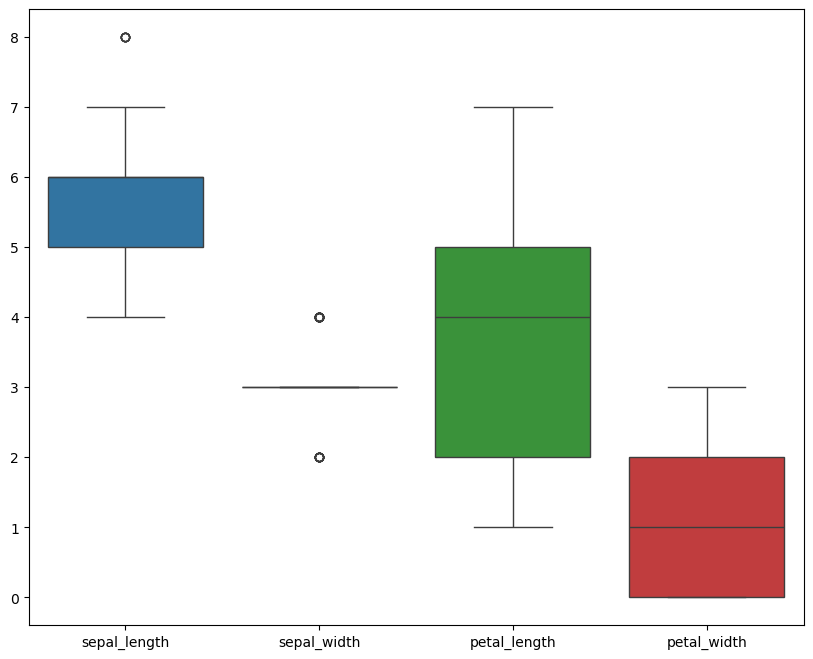

In [12]:
plt.figure(figsize=(10,8))
sns.boxplot(data)
plt.show()


<Axes: ylabel='Density'>

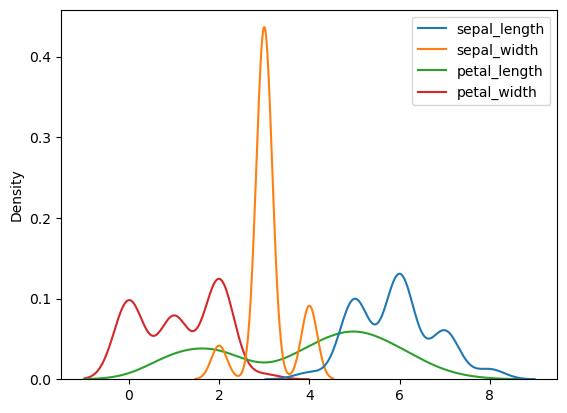

In [13]:
sns.kdeplot(data)

In [14]:
data["species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [15]:
LE=LabelEncoder()

In [16]:
data["species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [17]:
data["species"]=LE.fit_transform(data["species"])
data["species"].unique()

array([0, 1, 2])

In [18]:
#data["species"]=LE.inverse_transform(data["species"])
#data["species"].unique()

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   sepal_length  150 non-null    int64
 1   sepal_width   150 non-null    int64
 2   petal_length  150 non-null    int64
 3   petal_width   150 non-null    int64
 4   species       150 non-null    int64
dtypes: int64(5)
memory usage: 6.0 KB


In [20]:
X=data.drop("species",axis=1)
X

,sepal_length,sepal_width,petal_length,petal_width
0,5,4,1,0
1,5,3,1,0
2,5,3,1,0
3,5,3,2,0
4,5,4,1,0
...,...,...,...,...
145,7,3,5,2
146,6,3,5,2
147,7,3,5,2
148,6,3,5,2


In [21]:
y=data["species"]
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.shape

(120, 4)

In [24]:
y_train.shape

(120,)

In [25]:
X_test.shape

(30, 4)

In [26]:
y_test.shape

(30,)

In [27]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9
